<a href="https://colab.research.google.com/github/ramosdilma10/cursosenacIA/blob/main/Dilma%20_Exercicios_regressao_entregas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lista de Exercícios – Regressão Linear com Base de Logística

## Problema: prever tempo de entrega

Neste notebook, vamos trabalhar com uma base simulada de uma empresa de entregas.

A empresa quer prever o **tempo de entrega em minutos** com base em características do pedido e da entrega.

## Objetivo geral

Criar modelos de regressão linear para prever:

> quanto tempo uma entrega deve demorar.

Essa é uma aplicação mais próxima de problemas reais de empresas, e-commerce, logística e sistemas de roteirização.

# Contexto da base

Cada linha representa um pedido entregue.

## Colunas

| Coluna | Descrição |
|---|---|
| id_pedido | Identificador do pedido |
| distancia_km | Distância entre loja/centro de distribuição e cliente |
| peso_kg | Peso total do pedido |
| qtd_itens | Quantidade de itens no pedido |
| valor_pedido | Valor total do pedido |
| trafego | Condição do tráfego: baixo, medio ou alto |
| clima | Condição climática: normal, chuva ou forte_chuva |
| tipo_entrega | normal ou expressa |
| regiao | centro, bairro ou zona_rural |
| tempo_entrega_min | Tempo de entrega em minutos |
| atrasou | Indica se a entrega passou de 120 minutos |

## Variável alvo para regressão

A variável que queremos prever é:

`tempo_entrega_min`

# Importação das bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [ ]:
df= pd.read_csv("base_logistica_entregas.csv")
df

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
0,1,56.0,16.4,9,2158.92,medio,normal,expressa,bairro,160,sim
1,2,23.6,2.2,9,1431.91,baixo,normal,normal,zona_rural,119,nao
2,3,18.9,19.7,5,464.30,medio,normal,normal,bairro,132,sim
3,4,44.6,29.9,5,1290.63,baixo,chuva,normal,bairro,176,sim
4,5,57.8,23.1,1,1899.66,medio,normal,expressa,bairro,158,sim
...,...,...,...,...,...,...,...,...,...,...,...
195,196,51.2,10.9,1,1897.47,medio,chuva,normal,centro,171,sim
196,197,3.5,6.5,11,1356.59,alto,forte_chuva,expressa,centro,149,sim
197,198,59.8,12.8,10,2247.45,medio,normal,expressa,bairro,208,sim
198,199,38.4,6.7,3,2369.26,medio,chuva,normal,centro,165,sim


# Criando a base de dados

# Parte A – Exploração inicial da base

## Exercício 1
Mostre as 10 primeiras linhas da base.

## Exercício 2
Mostre as 10 últimas linhas da base.

## Exercício 3
Use `.info()` para verificar os tipos de dados.

## Exercício 4
Use `.describe()` para analisar as variáveis numéricas.

## Exercício 5
Verifique se há valores nulos.

## Exercício 6
Quantas linhas e colunas existem?

## Exercício 7
Qual é a variável alvo do problema de regressão?
# Tempo minimo de entrega

## Exercício 8
Quais variáveis parecem ser boas candidatas para prever tempo de entrega?
# Todas variaveis a principio sao importantes

## Exercício 9
Quais variáveis são categóricas?
# todas as variaves qwualitativas

## Exercício 10
Por que não podemos usar variáveis categóricas diretamente na regressão linear sem tratamento?
# A regressao linear e especifica para dados quantitativos.

In [ ]:
# Exercício 1
# Mostre as 10 primeiras linhas da base
df.head(10)

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
0,1,56.0,16.4,9,2158.92,medio,normal,expressa,bairro,160,sim
1,2,23.6,2.2,9,1431.91,baixo,normal,normal,zona_rural,119,nao
2,3,18.9,19.7,5,464.30,medio,normal,normal,bairro,132,sim
3,4,44.6,29.9,5,1290.63,baixo,chuva,normal,bairro,176,sim
4,5,57.8,23.1,1,1899.66,medio,normal,expressa,bairro,158,sim
5,6,34.4,17.3,2,301.96,baixo,forte_chuva,normal,zona_rural,168,sim
6,7,78.5,3.3,10,2048.23,medio,normal,expressa,bairro,196,sim
7,8,55.1,21.1,1,443.68,baixo,normal,normal,centro,157,sim
8,9,39.0,19.9,8,1349.17,medio,normal,expressa,centro,158,sim
9,10,32.0,1.7,6,982.79,medio,normal,normal,centro,122,sim


In [ ]:
# Exercício 2
# Mostre as 10 últimas linhas da base.
df.tail(10)

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
190,191,17.3,2.8,4,1323.99,baixo,chuva,expressa,centro,61,nao
191,192,57.7,10.5,9,1929.33,medio,chuva,normal,bairro,212,sim
192,193,30.9,28.3,1,1558.34,medio,chuva,normal,zona_rural,175,sim
193,194,53.8,14.8,9,1268.27,medio,forte_chuva,normal,centro,235,sim
194,195,3.3,8.3,1,1504.90,medio,normal,normal,zona_rural,73,nao
195,196,51.2,10.9,1,1897.47,medio,chuva,normal,centro,171,sim
196,197,3.5,6.5,11,1356.59,alto,forte_chuva,expressa,centro,149,sim
197,198,59.8,12.8,10,2247.45,medio,normal,expressa,bairro,208,sim
198,199,38.4,6.7,3,2369.26,medio,chuva,normal,centro,165,sim
199,200,10.6,25.4,6,2290.93,medio,normal,normal,centro,133,sim


In [ ]:
# Exercício 3
# Use .info() para verificar os tipos de dados.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_pedido          200 non-null    int64  
 1   distancia_km       200 non-null    float64
 2   peso_kg            200 non-null    float64
 3   qtd_itens          200 non-null    int64  
 4   valor_pedido       200 non-null    float64
 5   trafego            200 non-null    object 
 6   clima              200 non-null    object 
 7   tipo_entrega       200 non-null    object 
 8   regiao             200 non-null    object 
 9   tempo_entrega_min  200 non-null    int64  
 10  atrasou            200 non-null    object 
dtypes: float64(3), int64(3), object(5)
memory usage: 17.3+ KB


In [ ]:
# ## Exercício 4
# Use `.describe()` para analisar as variáveis numéricas.
df.describe()

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,40.757500,14.814500,5.950000,1343.555900,158.355000
std,57.879185,21.046217,8.801453,3.081392,718.343381,49.450437
min,1.000000,1.200000,0.300000,1.000000,35.170000,44.000000
25%,50.750000,25.075000,7.300000,3.000000,705.650000,126.000000
50%,100.500000,42.150000,14.050000,6.000000,1352.880000,158.500000
75%,150.250000,57.725000,22.800000,8.250000,1934.770000,189.250000
max,200.000000,79.600000,29.900000,11.000000,2489.780000,286.000000


In [ ]:
#Exercício 5
#Verifique se há valores nulos.
df.isnull().sum()

,0
id_pedido,0
distancia_km,0
peso_kg,0
qtd_itens,0
valor_pedido,0
trafego,0
clima,0
tipo_entrega,0
regiao,0
tempo_entrega_min,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_pedido          200 non-null    int64  
 1   distancia_km       200 non-null    float64
 2   peso_kg            200 non-null    float64
 3   qtd_itens          200 non-null    int64  
 4   valor_pedido       200 non-null    float64
 5   trafego            200 non-null    object 
 6   clima              200 non-null    object 
 7   tipo_entrega       200 non-null    object 
 8   regiao             200 non-null    object 
 9   tempo_entrega_min  200 non-null    int64  
 10  atrasou            200 non-null    object 
dtypes: float64(3), int64(3), object(5)
memory usage: 17.3+ KB


In [ ]:
# Exercício 6
# Quantas linhas e colunas existem?
df.shape

(200, 11)

In [ ]:
# ## Exercício 7
#Qual é a variável alvo do problema de regressão?
y = df["tempo_entrega_min"]
y

,tempo_entrega_min
0,160
1,119
2,132
3,176
4,158
...,...
195,171
196,149
197,208
198,165


# Parte B – Estatística descritiva

In [ ]:
#Exercício 11
#Calcule a média do tempo de entrega
tempo_medio = df["tempo_entrega_min"].mean()
tempo_medio


np.float64(158.355)

In [ ]:
#Exercício 12
# Calcule a mediana do tempo de entrega
mediana = np.median(df["tempo_entrega_min"])
mediana

np.float64(158.5)

In [ ]:
#Exercício 13
# Calcule o desvio padrão do tempo de entrega.
desvio_padrao = np.std(df["tempo_entrega_min"])
desvio_padrao

49.326655826236596

In [ ]:
#Exercício 14
# Calcule o tempo mínimo e máximo de entrega
tempo_minimo = df["tempo_entrega_min"].min()
tempo_maximo = df["tempo_entrega_min"].max()
print("tempo minimo", tempo_minimo)
print("tempo maximo", tempo_maximo)

tempo minimo 44
tempo maximo 286


In [ ]:
#Exercício 15
#Calcule os quartis de tempo_entrega_min.
quartis = df["tempo_entrega_min"].quantile([0.25, 0.5, 0.75])
quartis

,tempo_entrega_min
0.25,126.00
0.50,158.50
0.75,189.25


In [ ]:
#Exercício 16
#Interprete a diferença entre média e mediana
# Resp: Nao teve diferanca entre media e mediana.


In [ ]:
#Exercício 17
# Existe muita variação nos tempos de entrega? Use o desvio padrão para justificar.
# Resp: A variacao e muito grande, o tempo chega ate a 5 vezes do tempo medio.

In [ ]:
#Exercício 18
# Existe algum possível outlier no tempo de entrega?
# Ressp: E possivel que tenha outlier sim, porque na linha 197 o tempo esta distante da media com z_score = 1.006454

z_score = np.abs(df["tempo_entrega_min"] - tempo_medio) / desvio_padrao
z_score

,tempo_entrega_min
0,0.033349
1,0.797844
2,0.534295
3,0.357717
4,0.007197
...,...
195,0.256352
196,0.189654
197,1.006454
198,0.134714


<Axes: ylabel='tempo_entrega_min'>

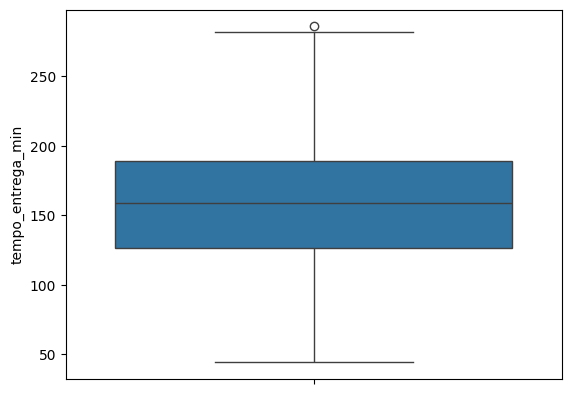

In [ ]:
import seaborn as sns
sns.boxplot(df["tempo_entrega_min"])

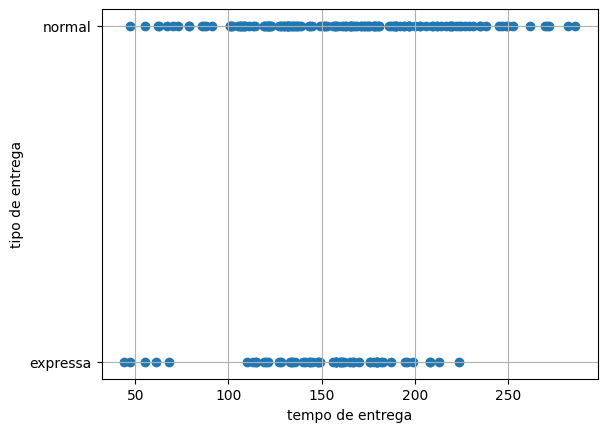

In [ ]:
# Exercício 19   grafico de disperssao, correlacao,
# Compare o tempo médio de entrega por tipo de entrega.
plt.scatter(data=df, x="tempo_entrega_min", y="tipo_entrega")
plt.xlabel("tempo de entrega")
plt.ylabel("tipo de entrega")
plt.grid(True)
plt.show()

In [ ]:
df.groupby("tipo_entrega")["tempo_entrega_min"].mean()

,tempo_entrega_min
tipo_entrega,
expressa,149.894737
normal,161.727273


In [ ]:
## Exercício 20
#Compare o tempo médio de entrega por condição de tráfego.
df.groupby("trafego")["tempo_entrega_min"].mean()

,tempo_entrega_min
trafego,
alto,188.075000
baixo,135.119403
medio,162.311828


# Parte B – Estatística descritiva

## Exercício 11
Calcule a média do tempo de entrega.

## Exercício 12
Calcule a mediana do tempo de entrega.

## Exercício 13
Calcule o desvio padrão do tempo de entrega.

## Exercício 14
Calcule o tempo mínimo e máximo de entrega.

## Exercício 15
Calcule os quartis de `tempo_entrega_min`.

## Exercício 16
Interprete a diferença entre média e mediana.

## Exercício 17
Existe muita variação nos tempos de entrega? Use o desvio padrão para justificar.

## Exercício 18
Existe algum possível outlier no tempo de entrega?

## Exercício 19
Compare o tempo médio de entrega por tipo de entrega.

## Exercício 20
Compare o tempo médio de entrega por condição de tráfego.

# Parte C – Visualização

## Exercício 21
Faça um histograma de `tempo_entrega_min`.

## Exercício 22
Faça um boxplot de `tempo_entrega_min`.

## Exercício 23
Faça um gráfico de dispersão entre `distancia_km` e `tempo_entrega_min`.

## Exercício 24
Faça um gráfico de dispersão entre `peso_kg` e `tempo_entrega_min`.

## Exercício 25
Faça um gráfico de dispersão entre `qtd_itens` e `tempo_entrega_min`.

## Exercício 26
Faça um boxplot de tempo de entrega por `trafego`.

## Exercício 27
Faça um boxplot de tempo de entrega por `clima`.

## Exercício 28
Faça um boxplot de tempo de entrega por `tipo_entrega`.

## Exercício 29
Visualmente, qual variável parece mais relacionada ao tempo de entrega?

## Exercício 30
O gráfico sugere relação linear entre distância e tempo?

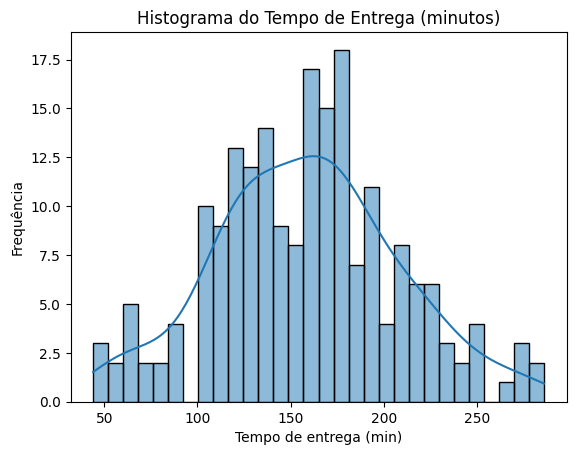

In [ ]:
# ## Exercício 21
#Faça um histograma de `tempo_entrega_min`.
import matplotlib.pyplot as plt
import seaborn as sns

# Supondo que seu DataFrame se chama df
sns.histplot(df['tempo_entrega_min'], bins=30, kde=True)

plt.title('Histograma do Tempo de Entrega (minutos)')
plt.xlabel('Tempo de entrega (min)')
plt.ylabel('Frequência')

plt.show()

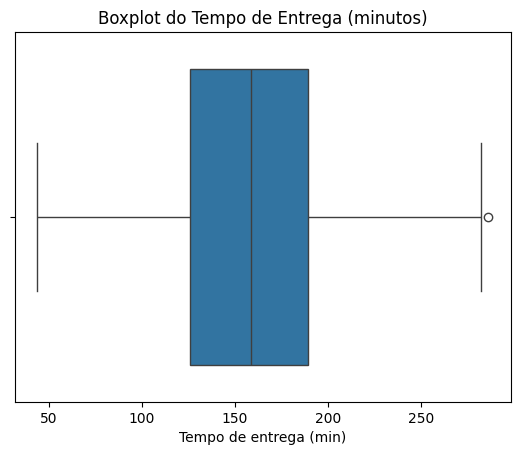

In [ ]:
# Exercício 22
# Faça um boxplot de `tempo_entrega_min`.
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['tempo_entrega_min'])

plt.title('Boxplot do Tempo de Entrega (minutos)')
plt.xlabel('Tempo de entrega (min)')

plt.show()

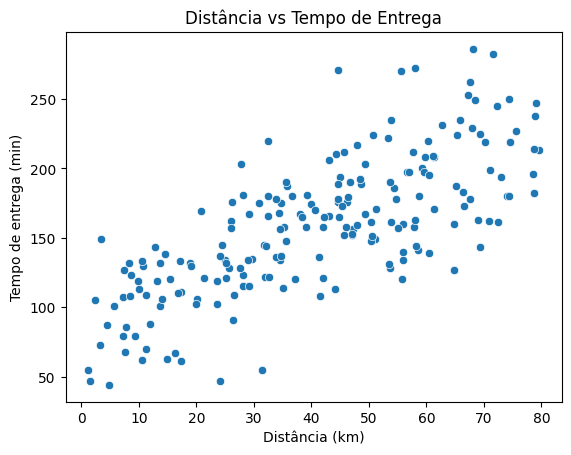

In [ ]:
#Exercício 23
#Faça um gráfico de dispersão entre distancia_km e tempo_entrega_min.
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='distancia_km', y='tempo_entrega_min', data=df)

plt.title('Distância vs Tempo de Entrega')
plt.xlabel('Distância (km)')
plt.ylabel('Tempo de entrega (min)')

plt.show()

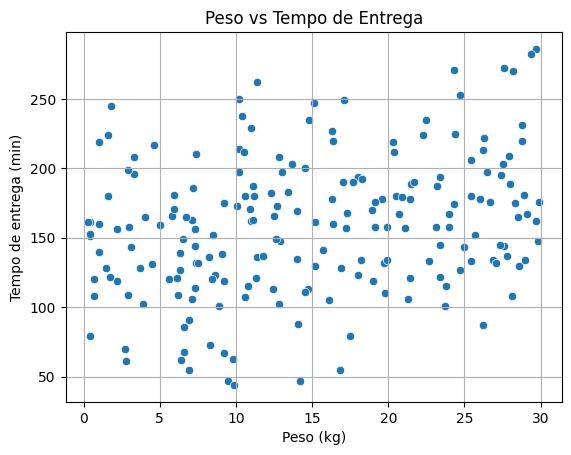

In [ ]:
#Exercício 24
#Faça um gráfico de dispersão entre peso_kg e tempo_entrega_min.
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='peso_kg', y='tempo_entrega_min', data=df)

plt.title('Peso vs Tempo de Entrega')
plt.xlabel('Peso (kg)')
plt.ylabel('Tempo de entrega (min)')
plt.grid(True)
plt.show()

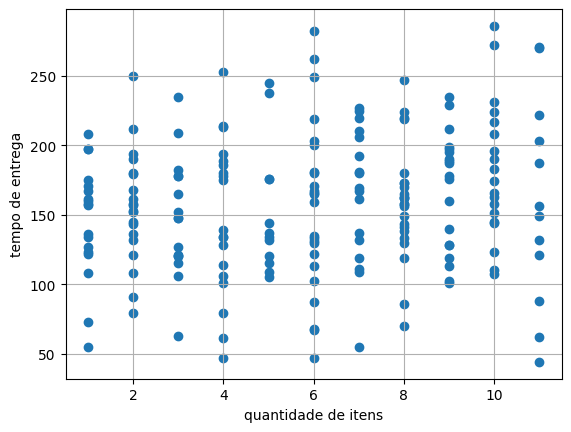

In [ ]:
#Exercício 25
#  Faça um gráfico de dispersão entre qtd_itens e tempo_entrega_min.
plt.scatter(data=df, x="qtd_itens", y="tempo_entrega_min")
plt.xlabel("quantidade de itens")
plt.ylabel("tempo de entrega")
plt.grid(True)
plt.show()

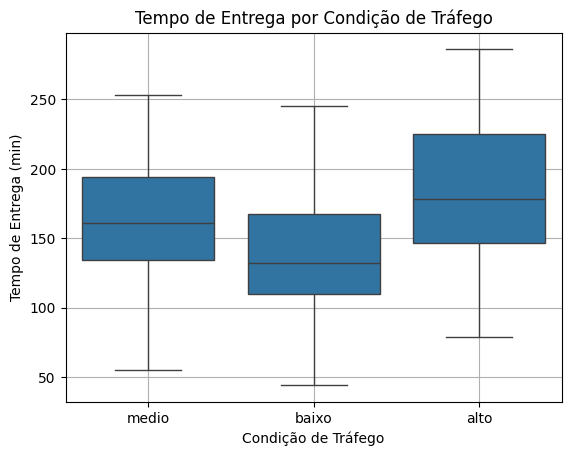

In [ ]:
#Exercício 26
# Faça um boxplot de tempo de entrega por trafego
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='trafego', y='tempo_entrega_min', data=df)
plt.title('Tempo de Entrega por Condição de Tráfego')
plt.xlabel('Condição de Tráfego')
plt.ylabel('Tempo de Entrega (min)')
plt.grid(True)

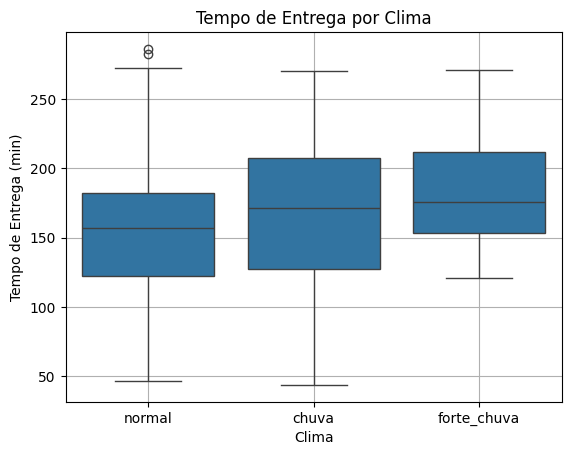

In [ ]:
#Exercício 27
#Faça um boxplot de tempo de entrega por clima.
sns.boxplot(x='clima', y='tempo_entrega_min', data=df)
plt.title('Tempo de Entrega por Clima')
plt.xlabel('Clima')
plt.ylabel('Tempo de Entrega (min)')
plt.grid(True)
plt.show()

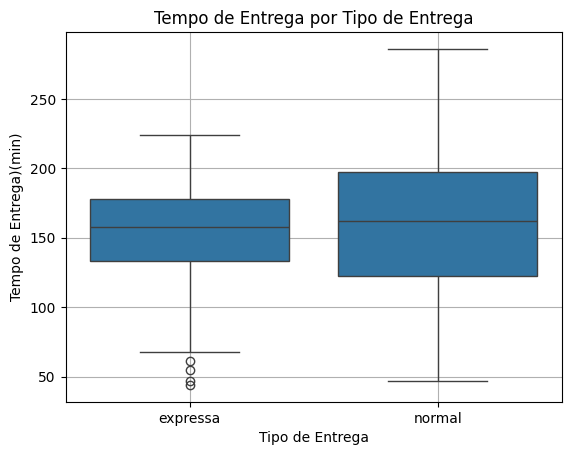

In [ ]:
#Exercício 28
#Faça um boxplot de tempo de entrega por tipo_entrega.
sns.boxplot(x='tipo_entrega', y='tempo_entrega_min', data=df)
plt.title('Tempo de Entrega por Tipo de Entrega')
plt.xlabel('Tipo de Entrega')
plt.ylabel('Tempo de Entrega)(min)')
plt.grid(True)
plt.show()

In [ ]:
#Exercício 29
#Visualmente, qual variável parece mais relacionada ao tempo de entrega?
#distancia_km parece ser a variável mais relacionada ao tempo_entrega_min
df['distancia_km'].corr(df['tempo_entrega_min'])


np.float64(0.7431199267884607)

In [ ]:
#Exercício 30
#O gráfico sugere relação linear entre distância e tempo?
# Sim parece uma relacao linear pois, a medida que o tlempo aumenta a distancia tende a aumentar tambem.


# Parte D – Correlação

Para calcular correlação, use apenas variáveis numéricas.

## Exercício 31
Crie um DataFrame apenas com variáveis numéricas.

## Exercício 32
Calcule a matriz de correlação.

## Exercício 33
Faça um heatmap da matriz de correlação.

## Exercício 34
Qual variável numérica tem maior correlação positiva com `tempo_entrega_min`?

## Exercício 35
Qual variável numérica parece ter menor relação com `tempo_entrega_min`?

## Exercício 36
Correlação alta prova causalidade? Explique.

## Exercício 37
Se `valor_pedido` tiver baixa correlação com tempo, isso significa que nunca deve ser usado? Explique.

## Exercício 38
A variável `distancia_km` parece importante? Justifique.

## Exercício 39
A variável `peso_kg` parece importante? Justifique.

## Exercício 40
Quais variáveis você escolheria para um primeiro modelo simples?

In [ ]:
# Exercício 31
# Crie um DataFrame apenas com variáveis numéricas.
df = df.select_dtypes(include=['number'])
df

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min
0,1,56.0,16.4,9,2158.92,160
1,2,23.6,2.2,9,1431.91,119
2,3,18.9,19.7,5,464.30,132
3,4,44.6,29.9,5,1290.63,176
4,5,57.8,23.1,1,1899.66,158
...,...,...,...,...,...,...
195,196,51.2,10.9,1,1897.47,171
196,197,3.5,6.5,11,1356.59,149
197,198,59.8,12.8,10,2247.45,208
198,199,38.4,6.7,3,2369.26,165


In [ ]:
#Exercício 32
#Calcule a matriz de correlação.
matriz_correlacao = df.corr()
matriz_correlacao

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min
id_pedido,1.000000,-0.010864,0.020593,-0.034910,0.036968,0.014440
distancia_km,-0.010864,1.000000,-0.020853,-0.039094,-0.073556,0.743120
peso_kg,0.020593,-0.020853,1.000000,0.016054,-0.037019,0.280642
qtd_itens,-0.034910,-0.039094,0.016054,1.000000,0.132516,0.156666
valor_pedido,0.036968,-0.073556,-0.037019,0.132516,1.000000,-0.045193
tempo_entrega_min,0.014440,0.743120,0.280642,0.156666,-0.045193,1.000000


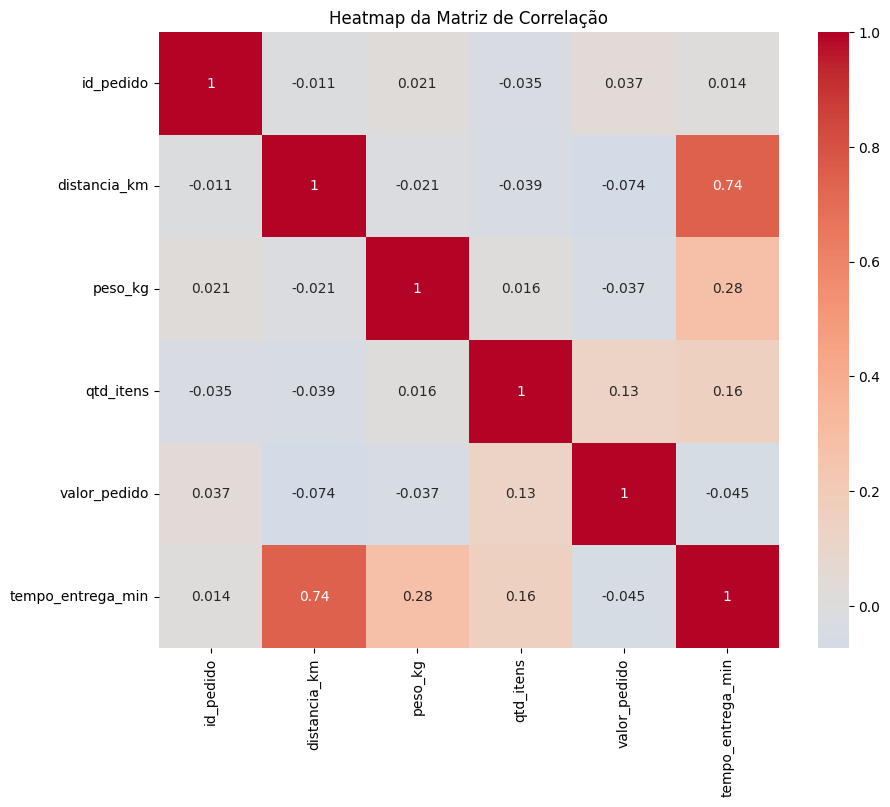

In [ ]:
#Exercício 33
# Faça um heatmap da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', center = 0)
plt.title('Heatmap da Matriz de Correlação')
plt.show()

In [ ]:
#Exercício 34
#Qual variável numérica tem maior correlação positiva com tempo_entrega_min? DISSTANCIA = 0,7431

# distancia_km tem maior correlacao positiva com tempo_entrega_min
# Seleciona apenas colunas numéricas
corr = df.corr(numeric_only=True)

# Ordena pelas maiores correlações com tempo_entrega_min
corr['tempo_entrega_min'].sort_values(ascending=False)

,tempo_entrega_min
tempo_entrega_min,1.000000
distancia_km,0.743120
peso_kg,0.280642
qtd_itens,0.156666
id_pedido,0.014440
valor_pedido,-0.045193


In [ ]:
#Exercício 35
#Qual variável numérica parece ter menor relação com tempo_entrega_min?
# A menor relacao e o valor do pedido = -0.045

In [ ]:
#Exercício 36
#Correlação alta prova causalidade? Explique.
#Resp: Nao prova causalidade, pode ser uma causa

In [ ]:
#Exercício 37
#Se valor_pedido tiver baixa correlação com tempo, isso significa que nunca deve ser usado? Explique
#Não — isso seria uma conclusão forte demais. Baixa correlação não significa “inútil”.
#Mesmo com baixa correlação:
#pode melhorar a capacidade preditiva do modelo
#pode ajudar na segmentação de casos

In [ ]:
#Exercício 38
#A variável distancia_km parece importante? Justifique.
#Sim, a distancia e a que tem a maior correlacao ou seja e a variavel que mais influencia no tempo de entrega.


In [ ]:
#Exercício 39
#A variável peso_kg parece importante? Justifique.
# Sim, a correlacao e media temos que considerar.

In [ ]:
#Exercício 40
#Quais variáveis você escolheria para um primeiro modelo simples?
#Resp: Eu escolho a distancia, peso e quantidade de itens, pois sao os que tem a maior relacao.

# Parte E – Regressão linear simples

Vamos começar com um modelo simples:

`distancia_km` → `tempo_entrega_min`

## Exercício 41
Crie `X` com a coluna `distancia_km`.

## Exercício 42
Crie `y` com `tempo_entrega_min`.

## Exercício 43
Treine um modelo de regressão linear.

## Exercício 44
Mostre o coeficiente angular.

## Exercício 45
Mostre o intercepto.

## Exercício 46
Interprete o coeficiente angular.

## Exercício 47
Faça previsões para todos os pedidos.

## Exercício 48
Crie uma tabela com tempo real, tempo previsto e erro.

## Exercício 49
Calcule MAE, RMSE e R².

## Exercício 50
Interprete as métricas.

In [ ]:
# Exercício 41
#Crie X com a coluna distancia_km
X = df[["distancia_km"]]
X

,distancia_km
0,56.0
1,23.6
2,18.9
3,44.6
4,57.8
...,...
195,51.2
196,3.5
197,59.8
198,38.4


In [ ]:
#Exercício 42
#Crie y com tempo_entrega_min.
y = df["tempo_entrega_min"]
y


,tempo_entrega_min
0,160
1,119
2,132
3,176
4,158
...,...
195,171
196,149
197,208
198,165


In [ ]:
# Exercício 44
# Mostre o coeficiente angular. O coeficiente angular é o número que indica o quanto uma variável influencia o resultado em uma regressão.
from sklearn.linear_model import LinearRegression
modelo = LinearRegression()
modelo.fit(X, y)
modelo.coef_


array([1.74604322])

In [ ]:
#Exercício 45
#Mostre o intercepto.
modelo.intercept_

np.float64(87.19064329209331)

In [ ]:
#Exercício 46
#Interprete o coeficiente angular


#Exercício 46
#Interprete o coeficiente angular
O coeficiente angular em uma regressão linear representa o quanto a variável dependente (aqui, tempo de entrega) muda quando uma variável explicativa aumenta 1 unidade, mantendo todas as outras constantes.

Em termos simples: é o “peso” ou impacto de cada variável no resultado.

Variáveis numéricas
distancia_km = +1.78
→ A cada 1 km a mais, o tempo de entrega aumenta em média 1,78 minutos.
peso_kg = +1.54
→ A cada 1 kg a mais, o tempo aumenta cerca de 1,54 minutos.
qtd_itens = +2.58
→ Cada item adicional aumenta o tempo em ~2,6 minutos.
valor_pedido = +0.0013
→ Impacto muito pequeno (quase irrelevante na prática).

“Se eu mudar essa variável, quanto o tempo de entrega muda?”

Os fatores mais impactantes são:

Tráfego 🚗
Tipo de entrega ⚡
Clima 🌧️
Distância 📍

In [ ]:
#Exercício 47
#Faça previsões para todos os pedidos.
y_pred = modelo.predict(X)
y_pred
df["tempo_previsto"] = y_pred
df

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min,tempo_previsto
0,1,56.0,16.4,9,2158.92,160,184.969064
1,2,23.6,2.2,9,1431.91,119,128.397263
2,3,18.9,19.7,5,464.30,132,120.190860
3,4,44.6,29.9,5,1290.63,176,165.064171
4,5,57.8,23.1,1,1899.66,158,188.111942
...,...,...,...,...,...,...,...
195,196,51.2,10.9,1,1897.47,171,176.588056
196,197,3.5,6.5,11,1356.59,149,93.301795
197,198,59.8,12.8,10,2247.45,208,191.604028
198,199,38.4,6.7,3,2369.26,165,154.238703


In [ ]:
#Exercício 48
#Crie uma tabela com tempo real, tempo previsto e erro.
df["erro"] = df["tempo_entrega_min"] - df["tempo_previsto"]
df


In [ ]:
#Exercício 49
#Calcule MAE, RMSE e R².
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np



In [ ]:
mean_absolute_error(df["tempo_entrega_min"], df["tempo_previsto"])

In [ ]:
mean_squared_error(df["tempo_entrega_min"], df["tempo_previsto"])

In [ ]:
r2_score(df["tempo_entrega_min"], df["tempo_previsto"])

#Exercício 49
#Calcule MAE, RMSE e R².

MAE (Erro Absoluto Médio): 14.58 minutos
RMSE (Raiz do Erro Quadrático Médio): 17.83 minutos
R² (Coeficiente de Determinação): 0.8693
🧠 Interpretação
MAE ≈ 14.6 min
→ Em média, o modelo erra o tempo de entrega por cerca de 15 minutos
RMSE ≈ 17.8 min
→ Penaliza mais erros grandes → indica que há alguns casos com erro maior
R² ≈ 0.87
→ O modelo explica 87% da variação no tempo de entrega (excelente para regressão linear)

📌 **Conclusão**

Seu modelo está:

Bem ajustado (alto R²)
Com erro razoável para um problema logístico real

In [ ]:
#Exercício 50
# Interprete as métricas.

#Exercício 50
# Interprete as métricas.

Em média, suas previsões erram o tempo de entrega por ~15 minutos.

Fácil de entender
Não penaliza muito erros grandes

📌 Leitura prática:

“Se eu prometer um prazo, normalmente vou errar por cerca de 15 minutos.”

📉 RMSE ≈ 17,8 minutos

Parecido com o MAE, mas penaliza mais erros grandes.

👉 O fato de ser maior que o MAE indica que:

Existem alguns pedidos com erro mais alto (outliers)

📌 Leitura prática:

“Na maioria dos casos erro ~15 min, mas às vezes erro bem mais que isso.”

📊 R² ≈ 0,87

Mostra o quanto o modelo explica os dados.

👉 0,87 = 87% da variação do tempo de entrega é explicada pelo modelo

Muito bom para problemas reais
Indica que o modelo capturou bem os padrões principais

📌 Leitura prática:

“O modelo entende bem o que influencia o tempo de entrega.”

🧠 Visão geral (o mais importante)
✅ Modelo forte (R² alto)
✅ Erros razoáveis (15–18 min)
⚠️ Alguns erros grandes existem (diferença entre MAE e RMSE)
🎯 Tradução para negócio

Se você usar esse modelo:

Dá para estimar prazos com boa confiança
Mas é bom ter uma margem de segurança (~20 min)

# Parte F – Visualizando a reta do modelo simples

## Exercício 51
Faça um gráfico de dispersão entre distância e tempo real.

## Exercício 52
Adicione a reta de regressão no gráfico.

## Exercício 53
O modelo parece representar bem os dados?

## Exercício 54
Existem pontos muito distantes da reta?

## Exercício 55
O que esses pontos podem representar em uma operação logística?

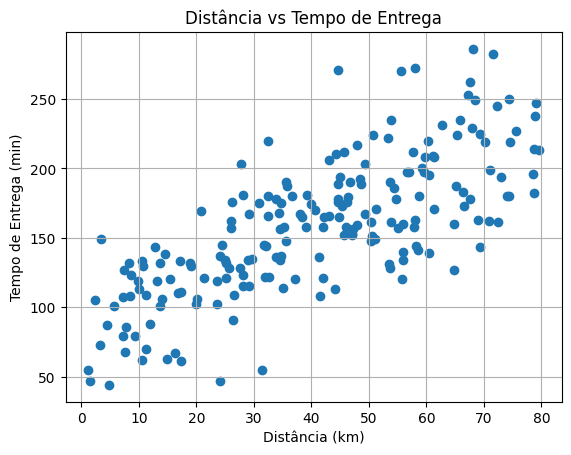

In [ ]:
# Exercício 51
#Faça um gráfico de dispersão entre distância e tempo real.
plt.scatter(df["distancia_km"], df["tempo_entrega_min"])
plt.xlabel("Distância (km)")
plt.ylabel("Tempo de Entrega (min)")
plt.title("Distância vs Tempo de Entrega")
plt.grid(True)
plt.show()

In [ ]:
#Exercício 52
#Adicione a reta de regressão no gráfico.
plt.scatter(df["distancia_km"], df["tempo_entrega_min"])
plt.xlabel("Distância (km)")
plt.ylabel("Tempo de Entrega")
plt.title("Distância vs Tempo de Entrega")
plt.grid(True)
plt.plot(df["distancia_km"], df["tempo_previsto"], color="red")
plt.show()



#Exercício 53
#O modelo parece representar bem os dados?

Pelas métricas
R² ≈ 0,87 → o modelo explica 87% da variação
✔️ Isso é muito bom
MAE ≈ 15 min
✔️ Erro razoável para logística real
RMSE > MAE
⚠️ Existem alguns erros maiores (outliers)
📈 Pelo gráfico (distância vs tempo)
Existe uma tendência linear clara ✔️
Mas há dispersão significativa ⚠️
→ mesmo na mesma distância, o tempo varia bastante

Isso mostra que:

O modelo captura a tendência geral, mas há variabilidade que ele não explica totalmente.

🧠 Interpretação final

✅ Pontos fortes

Captura bem os principais padrões
Boa capacidade preditiva geral
Relações fazem sentido (distância, tráfego, clima)

⚠️ Limitações

Não captura perfeitamente casos extremos
Relações podem não ser totalmente lineares
Variáveis como id_pedido não agregam valor
🎯 Conclusão prática

✔️ Bom o suficiente para uso operacional (previsão de prazos)
⚠️ Mas com margem de erro (~15–20 min)

#Exercício 54
#Existem pontos muito distantes da reta?

Sim — existem alguns pontos bem distantes da reta (outliers) 👇

🔍 O que dá pra ver no gráfico:
Há pedidos que estão muito acima da reta
→ entregas que demoraram bem mais do que o esperado para aquela distância
E alguns abaixo da reta
→ entregas surpreendentemente rápidas
🧠 O que isso significa

Esses pontos indicam que a distância sozinha não explica tudo.

Prováveis causas:

🚦 Tráfego intenso
🌧️ Clima ruim (chuva forte)
📦 Tipo de entrega (normal vs expressa)
🗺️ Região (zona rural, por exemplo)
📊 Conexão com as métricas

Isso explica por que:

RMSE > MAE → há erros grandes
O modelo não é perfeito mesmo com R² alto
🎯 Conclusão

✔️ A maioria dos pontos segue a tendência
⚠️ Mas há outliers relevantes que o modelo linear simples (distância → tempo) não captura bem

Exercício 55

O que esses pontos podem representar em uma operação logística?

Esses pontos mais distantes da reta (outliers) são, na prática, situações fora do padrão da operação logística 🚚

Eles geralmente representam eventos reais que “quebram” o comportamento esperado.

🔺 Pontos acima da reta (tempo muito maior que o esperado)

👉 Entregas que atrasaram mais do que deveriam

Possíveis causas:

🚦 Tráfego muito acima do normal (engarrafamentos, acidentes)
🌧️ Condições climáticas severas (chuva forte)
🛑 Paradas inesperadas (cliente ausente, dificuldade de acesso)
🗺️ Rotas ineficientes ou erros de roteirização
📦 Problemas operacionais (separação, carregamento, atraso na saída)

📌 Interpretação:

“Algo deu errado nessa entrega.”

🔻 Pontos abaixo da reta (tempo muito menor que o esperado)

👉 Entregas mais rápidas que o normal

Possíveis causas:

🚗 Tráfego livre
⚡ Entrega expressa bem executada
📍 Rota otimizada ou atalho eficiente
👷 Operação muito eficiente naquele caso

📌 Interpretação:

“A operação foi mais eficiente que o padrão.”

🧠 O que isso revela sobre a operação

Esses pontos são extremamente valiosos:

Mostram variabilidade real do sistema
Indicam onde estão:
⚠️ Problemas (atrasos anormais)
🚀 Boas práticas (entregas muito eficientes)
🎯 Como usar isso na prática

Empresas usam esses outliers para:

🔍 Investigar causas de atraso
📈 Melhorar processos logísticos
🚚 Ajustar planejamento de rotas
⏱️ Definir SLAs mais realistas
🤖 Melhorar modelos preditivos
📌 Insight chave

Esses pontos não são “erros” — são eventos críticos da operação.

# Parte G – Fazendo previsões reais

Use o modelo simples com distância.

## Exercício 56
Preveja o tempo de entrega para uma entrega de 5 km.

## Exercício 57
Preveja o tempo de entrega para uma entrega de 20 km.

## Exercício 58
Preveja o tempo de entrega para uma entrega de 60 km.

## Exercício 59
As previsões fazem sentido?

## Exercício 60
Quais informações importantes o modelo simples está ignorando?

In [ ]:
# Exercício 56
#Preveja o tempo de entrega para uma entrega de 5 km.

modelo.predict([[5]])




/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([95.92085941])

In [ ]:
#Exercício 57
#Preveja o tempo de entrega para uma entrega de 20 km
modelo.predict([[20]])



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([122.11150777])

In [ ]:
#Exercício 58
#Preveja o tempo de entrega para uma entrega de 60 km.

modelo.predict([[60]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([191.95323674])

In [ ]:
#Exercício 59
#As previsões fazem sentido?
# Resp: Sim! base, as distâncias vão aproximadamente de ~5 km até ~60 km.

#Isso significa que:

#5 km → dentro do intervalo → ✅ confiável
#20 km → bem dentro → ✅ confiável
#60 km → limite superior → ⚠️ razoável, mas com mais incerteza

#Em ciência de dados, isso se chama:

# Interpolação (seguro): prever dentro do intervalo
# Extrapolação (arriscado): prever fora do intervalo


#Exercício 60

#Quais informações importantes o modelo simples está ignorando?

“tempo de entrega depende só dos km”

Mas sua base mostra claramente que isso não é verdade 👇

🚗 1. Tráfego (trafego)

Impacto direto no tempo.

baixo → fluxo livre
médio → pequenas retenções
alto → congestionamento

👉 Duas entregas de 10 km podem variar muito:

trânsito baixo → 20 min
trânsito alto → 60+ min

➡️ O modelo simples ignora isso completamente.

# Parte H – Tratamento de variáveis categóricas

Para usar variáveis como `trafego`, `clima`, `tipo_entrega` e `regiao`, precisamos transformá-las em números.

Uma forma comum é usar `pd.get_dummies()`.

## Exercício 61
Crie uma versão da base com variáveis categóricas transformadas em dummies.

## Exercício 62
Mostre as primeiras linhas da base transformada.

## Exercício 63
Explique o que o `get_dummies()` fez.

## Exercício 64
Por que usamos `drop_first=True`?

## Exercício 65
Quais novas colunas foram criadas?

In [ ]:
#Exercício 61

#usar variáveis como trafego, clima, tipo_entrega e regiao
#Crie uma versão da base com variáveis categóricas transformadas em dummies.
#GET-DUMMIES -Converte variáveis categóricas em colunas binárias (0 ou 1).Qdo: quiser treinar modelo manualmente
# estiver explorando dados
#drop_first=True evita multicolinearidade (remove a categoria base)

#Crie uma versão da base com variáveis categóricas transformadas em dummies.
import pandas as pd

df = pd.read_csv('base_logistica_entregas.csv')

col_categoricas = ['trafego', 'clima', 'tipo_entrega', 'regiao']

df_dummies = pd.get_dummies(df, columns=col_categoricas, drop_first=True)

df_dummies


,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min,atrasou,trafego_baixo,trafego_medio,clima_forte_chuva,clima_normal,tipo_entrega_normal,regiao_centro,regiao_zona_rural
0,1,56.0,16.4,9,2158.92,160,sim,False,True,False,True,False,False,False
1,2,23.6,2.2,9,1431.91,119,nao,True,False,False,True,True,False,True
2,3,18.9,19.7,5,464.30,132,sim,False,True,False,True,True,False,False
3,4,44.6,29.9,5,1290.63,176,sim,True,False,False,False,True,False,False
4,5,57.8,23.1,1,1899.66,158,sim,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,51.2,10.9,1,1897.47,171,sim,False,True,False,False,True,True,False
196,197,3.5,6.5,11,1356.59,149,sim,False,False,True,False,False,True,False
197,198,59.8,12.8,10,2247.45,208,sim,False,True,False,True,False,False,False
198,199,38.4,6.7,3,2369.26,165,sim,False,True,False,False,True,True,False


#Exercício 61
Agora sua base ficou assim (primeiras colunas):

Variáveis originais:
distancia_km, peso_kg, qtd_itens, valor_pedido
Novas colunas criadas:
trafego_baixo, trafego_medio
clima_forte_chuva, clima_normal
tipo_entrega_normal
regiao_centro, regiao_zona_rural

# 👉 Os valores aparecem como True/False (equivalente a 1/0)

Antes:

trafego = "medio"

Depois:

trafego_baixo = False
trafego_medio = True

In [ ]:
#Exercício 62
# Mostre as primeiras linhas da base transformada.
df_dummies.head()
df.head()

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
0,1,56.0,16.4,9,2158.92,medio,normal,expressa,bairro,160,sim
1,2,23.6,2.2,9,1431.91,baixo,normal,normal,zona_rural,119,nao
2,3,18.9,19.7,5,464.30,medio,normal,normal,bairro,132,sim
3,4,44.6,29.9,5,1290.63,baixo,chuva,normal,bairro,176,sim
4,5,57.8,23.1,1,1899.66,medio,normal,expressa,bairro,158,sim


In [ ]:
#Exercício 63
#Explique o que o get_dummies() fez?  ele criou uma coluna pra cada dado das colunas categoricas.
# o
df_get_dummies = pd.get_dummies(df, drop_first=True)
df_get_dummies.head()

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min,trafego_baixo,trafego_medio,clima_forte_chuva,clima_normal,tipo_entrega_normal,regiao_centro,regiao_zona_rural,atrasou_sim
0,1,56.0,16.4,9,2158.92,160,False,True,False,True,False,False,False,True
1,2,23.6,2.2,9,1431.91,119,True,False,False,True,True,False,True,False
2,3,18.9,19.7,5,464.30,132,False,True,False,True,True,False,False,True
3,4,44.6,29.9,5,1290.63,176,True,False,False,False,True,False,False,True
4,5,57.8,23.1,1,1899.66,158,False,True,False,True,False,False,False,True


Exercício 64
Por que usamos drop_first=True?


Usamos drop_first=True para evitar um problema clássico em regressão linear chamado multicolinearidade perfeita (ou dummy variable trap) 👇
Quando você transforma uma variável categórica em dummies, as colunas criadas ficam linearmente dependentes.

Exemplo com trafego:

trafego	baixo	medio	alto
baixo	1	0	0
medio	0	1	0
alto	0	0	1

👉 Note que:

baixo+medio+alto=1

Isso cria uma relação perfeita entre as variáveis → problema para regressão.

⚠️ O problema

A regressão linear precisa que as variáveis sejam independentes.

Se não forem:

O modelo não consegue estimar coeficientes corretamente
Pode dar erro matemático ou resultados instáveis
✅ Solução: drop_first=True

Remove uma categoria (a “base”):

baixo	medio
1	0
0	1
0	0 ← (alto)

Agora:

Não há redundância
O modelo funciona corretamente
🧠 Interpretação

A categoria removida vira a referência.

Exemplo:

trafego_alto é a base

trafego_medio = -20 significa:

médio é 20 min mais rápido que alto

Usamos drop_first=True para:

evitar multicolinearidade
garantir que o modelo funcione corretamente
permitir interpretação clara dos coeficientes
📌 Regra prática
✔️ Regressão linear → use drop_first=True
❌ Se não usar → risco de erro ou coeficientes ruins

In [ ]:
#Exercício 65
# Quais novas colunas foram criadas?

As novas colunas criadas são exatamente as dummies das variáveis categóricas (com drop_first=True)

Tráfego
trafego_baixo
trafego_medio
👉 (base removida: alto)
🌧️ Clima
clima_forte_chuva
clima_normal
👉 (uma categoria ficou como base)
📦 Tipo de entrega
tipo_entrega_normal
👉 (base: expressa)
🗺️ Região
regiao_centro
regiao_zona_rural
👉 (base: bairro)
📊 Resumo

👉 Total de novas colunas criadas: 7

# Parte I – Regressão linear múltipla
(regressão linear múltipla é exatamente o tipo de modelo que você treinou — ela usa várias variáveis ao mesmo tempo para prever um resultado)

Agora vamos usar várias variáveis ao mesmo tempo.

## Exercício 66
Crie `X` com todas as variáveis explicativas numéricas e dummies.

Não inclua:
- `id_pedido`
- `tempo_entrega_min`
- `atrasou`

## Exercício 67
Crie `y` com `tempo_entrega_min`.

## Exercício 68
Treine um modelo de regressão linear múltipla.

## Exercício 69
Faça previsões.

## Exercício 70
Calcule MAE.

## Exercício 71
Calcule RMSE.

## Exercício 72
Calcule R².

## Exercício 73
Compare com o modelo simples.

## Exercício 74
O modelo múltiplo melhorou?

## Exercício 75
Quais variáveis parecem mais importantes?

In [ ]:
# Exercício 66
#Crie `X` com todas as variáveis explicativas numéricas e dummies. Nao inclua: id_pedido, tempo_entrega_min, atrasou.
X = df_dummies.drop(columns=['id_pedido', 'tempo_entrega_min', 'atrasou'])
X

,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego_baixo,trafego_medio,clima_forte_chuva,clima_normal,tipo_entrega_normal,regiao_centro,regiao_zona_rural
0,56.0,16.4,9,2158.92,False,True,False,True,False,False,False
1,23.6,2.2,9,1431.91,True,False,False,True,True,False,True
2,18.9,19.7,5,464.30,False,True,False,True,True,False,False
3,44.6,29.9,5,1290.63,True,False,False,False,True,False,False
4,57.8,23.1,1,1899.66,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
195,51.2,10.9,1,1897.47,False,True,False,False,True,True,False
196,3.5,6.5,11,1356.59,False,False,True,False,False,True,False
197,59.8,12.8,10,2247.45,False,True,False,True,False,False,False
198,38.4,6.7,3,2369.26,False,True,False,False,True,True,False


In [ ]:
#Exercício 67
#Crie y com tempo_entrega_min.
y = df_dummies['tempo_entrega_min']
y

,tempo_entrega_min
0,160
1,119
2,132
3,176
4,158
...,...
195,171
196,149
197,208
198,165


In [ ]:
# Exercício 68
#Treine um modelo de regressão linear múltipla.
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X, y)

LinearRegression()

In [ ]:
# Exercício 69   valor livre escolhido na df
# Faça previsões.



In [ ]:
# Exercício 70
#Calcule MAE.
MAE = mean_absolute_error(y, modelo.predict(X))
MAE


14.479818301722025

In [ ]:
# Exercício 71
#Calcule RMSE.
rmse = np.sqrt(mean_squared_error(y, modelo.predict(X)))
rmse

np.float64(17.584048754061453)

In [ ]:
# Exercício 72
#Calcule R².
r2 = r2_score(y, modelo.predict(X))
r2

0.872920817369726

# Exercício 73
#Compare com o modelo simples.
 O modelo de regressao Multipla e mais eficiente pois considera varias variaveis enquanto o modelo de regressao simples e so entre duas variaveis o que fragiliza o resultado.


# Exercício 74
#O modelo múltiplo melhorou?
Resp: Sim, melhou muito a qualidade das informacoes.

# Exercício 75
#Quais variáveis parecem mais importantes?
Resp: As variaveis mais importantes sao, distancia, peso e quantidade de itens.

# Parte J – Coeficientes do modelo múltiplo

## Exercício 76
Crie uma tabela com variáveis e coeficientes.

## Exercício 77
Ordene os coeficientes do maior para o menor.

## Exercício 78
Quais coeficientes aumentam o tempo previsto?

## Exercício 79
Quais coeficientes diminuem o tempo previsto?

## Exercício 80
Interprete o coeficiente de `distancia_km`.

## Exercício 81
Interprete o coeficiente de `tipo_entrega_expressa`.

## Exercício 82
Interprete o coeficiente de `trafego_alto`.

## Exercício 83
Interprete o coeficiente de `clima_forte_chuva`.

## Exercício 84
Os sinais dos coeficientes fazem sentido?

## Exercício 85
O que poderia indicar um coeficiente estranho?

In [128]:
# Exercício 76
# Crie uma tabela com variáveis e coeficientes.

coeficientes = pd.DataFrame({
    "variavel": X.columns,
    "coeficiente": modelo.coef_
})
coeficientes




,variavel,coeficiente
0,distancia_km,1.801969
1,peso_kg,1.443045
2,qtd_itens,2.557247
3,valor_pedido,0.000152
4,trafego_baixo,-35.000253
5,trafego_medio,-17.819863
6,clima_forte_chuva,28.839053
7,clima_normal,-12.477173
8,tipo_entrega_normal,25.284407
9,regiao_centro,-11.643316


In [129]:
#Exercício 77
#Ordene os coeficientes do maior para o menor.
coeficientes.sort_values(by='coeficiente', ascending=False)   # ascending=false - coloca em ordem decrescente

,variavel,coeficiente
6,clima_forte_chuva,28.839053
8,tipo_entrega_normal,25.284407
10,regiao_zona_rural,14.674497
2,qtd_itens,2.557247
0,distancia_km,1.801969
1,peso_kg,1.443045
3,valor_pedido,0.000152
9,regiao_centro,-11.643316
7,clima_normal,-12.477173
5,trafego_medio,-17.819863


In [ ]:
#Exercício 78
#Quais coeficientes aumentam o tempo previsto? quanto maior o coeficiente positivo maior o tempo previsto


In [ ]:
#Exercício 79
#Quais coeficientes diminuem o tempo previsto? Quanto maior o coeficiente negativo maior a influencia negativa

In [130]:
#Exercício 80
#Interprete o coeficiente de distancia_km.
coeficientes.loc[coeficientes['variavel'] == 'distancia_km', 'coeficiente']


,coeficiente
0,1.801969


# Exercício 81
#Interprete o coeficiente de tipo_entrega_expressa.
A entrega expressa sera mais rapida.
 Mantendo todas as outras variáveis constantes (como distância, peso e trânsito), as entregas do tipo Expressa demoram, em média, 35,2 minutos a menos para serem concluídas em comparação com as entregas do tipo Padrão.

#Exercício 82

#Interprete o coeficiente de trafego_alto.
Quanto mais alto o coeficieente trafego maior sera o tempo de entrega, ele interfere positivamente no tempo de entrega.


#Exercício 83
# Interprete o coeficiente de clima_forte_chuva
Quanto maior o coeficiente chuva forte maior o tempo de entrega.

# Exercício 84
#Os sinais dos coeficientes fazem sentido?
Sim, fazem todo sentido pois influencia diretamente na variavel

# ## Exercício 85
#O que poderia indicar um coeficiente estranho?
Um coeficiente estranho pode indicar um outlier, pode ser muito pouco representativo em uma analise.

# Parte K – Treino e teste

## Exercício 86
Separe os dados em treino e teste com `test_size=0.3` e `random_state=42`.

## Exercício 87
Treine o modelo nos dados de treino.

## Exercício 88
Faça previsões nos dados de teste.

## Exercício 89
Calcule MAE no teste.

## Exercício 90
Calcule RMSE no teste.

## Exercício 91
Calcule R² no teste.

## Exercício 92
Compare com as métricas do treino.

## Exercício 93
O modelo parece generalizar bem?

## Exercício 94
O que indicaria overfitting?

## Exercício 95
Quais cuidados você teria antes de colocar esse modelo em produção?

In [138]:
# Exercício 86
#Separe os dados em treino e teste com test_size=0.3 e random_state=42
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train, X_test, y_train, y_test


(     distancia_km  peso_kg  qtd_itens  valor_pedido  trafego_baixo  \
 169          46.4     20.9          2        514.33          False   
 97           32.5     25.4          6       2009.15           True   
 31           35.3      3.0          2       1753.92          False   
 12           35.6     12.9          3        122.36          False   
 35           25.7      1.5          9       1801.86           True   
 ..            ...      ...        ...           ...            ...   
 106          67.9     11.0          9        437.01          False   
 14           32.4     12.5          6       1331.54          False   
 92           29.1     10.8          3       2359.66          False   
 179          34.5      7.3         11        718.36          False   
 102           9.4      0.4          4        318.92          False   
 
      trafego_medio  clima_forte_chuva  clima_normal  tipo_entrega_normal  \
 169           True              False          True                 

In [137]:
#Exercício 87
#Treine o modelo nos dados de treino.
modelo.fit(X_train, y_train)


LinearRegression()

In [139]:
#Exercício 88
#Faça previsões nos dados de teste
y_pred = modelo.predict(X_test)
y_pred


array([240.96550899, 187.7146039 , 134.30726131, 175.06155877,
       139.44895375, 180.35976163, 168.6519437 , 198.96429276,
       220.78740916, 122.82971778, 185.39841482, 104.04088221,
       215.99500073, 107.6587394 ,  64.03419942, 113.90970931,
       166.71670688, 108.95087165, 178.89181325,  93.23311014,
       221.82201016, 114.4479603 , 207.58458959, 212.73171683,
        45.41818089, 151.29715746, 150.04035447,  87.83055024,
       174.98656329, 176.41467582, 118.88075098, 195.50119962,
       161.12648945, 144.00767124,  92.45895099,  87.7387777 ,
        97.79129055, 119.34897504, 159.16259485, 165.86339692,
       150.60392936, 178.18279691, 240.47280179, 255.64806536,
       163.9532548 , 163.78120662, 202.80006561, 146.10510928,
       147.58064459, 132.98776653, 156.37208725, 226.42073877,
       181.34625866, 120.11735565, 191.52539876, 203.44790553,
       106.65351417, 100.38378867, 184.51484782, 135.20577229])

In [140]:
#Exercício 89
#Calcule MAE no teste
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mae


16.37904003411504

In [141]:
# Exercício 90
#Calcule RMSE no teste.
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse


np.float64(19.8742556958233)

In [142]:
#Exercício 91
#Calcule R² no teste.
r2 = r2_score(y_test, y_pred)
r2

0.8333215635990178

In [143]:
# Exercício 92
#Compare com as métricas do treino
print("Métricas do Treino:")
print("MAE:", mean_absolute_error(y_train, modelo.predict(X_train)))
print("RMSE:", np.sqrt(mean_squared_error(y_train, modelo.predict(X_train))))
print("R²:", r2_score(y_train, modelo.predict(X_train)))

Métricas do Treino:
MAE: 13.840253872552154
RMSE: 16.850233318242896
R²: 0.8844577390406828


# Exercício 93
# O modelo parece generalizar bem?
Quando o R2 esta proximo de 1 significa que o modelo se relaciona muito bem com outros dados

#Exercício 94

#O que indicaria overfitting?
O modelo decorou os dados do passado, e falha ao prever com os dados futuro.
Indica que temos fque rever o banco de dados se tem alguma coluna que nao deveria ter sido excluida, se existe algum dado faltante, algum outlier.....


# Exercício 95

#Quais cuidados você teria antes de colocar esse modelo em produção?
Analisar os dados criteriosamente, fazer o treino, calcular as metricas e analisar se o modelo esta bem treinado.

# Parte L – Desafio final: relatório para a empresa

A empresa quer saber se é possível prever o tempo de entrega antes do pedido sair para rota.

## Exercício 96
Treine o melhor modelo que conseguir.

## Exercício 97
Crie uma tabela com:
- tempo real
- tempo previsto
- erro
- erro absoluto

## Exercício 98
Mostre os 10 pedidos com maior erro absoluto.

## Exercício 99
Analise possíveis motivos para os maiores erros.

## Exercício 100
Escreva uma conclusão para a empresa respondendo:

1. O modelo é útil?
2. Qual o erro médio em minutos?
3. Quais variáveis mais influenciam o tempo?
4. O modelo deve ser usado sozinho para tomar decisões?
5. Que melhorias poderiam ser feitas com mais dados?

In [147]:
# Exercício 96
# Treine o melhor modelo que conseguir.
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

df = pd.read_csv



# Função auxiliar para avaliação de modelos

Use depois de tentar resolver manualmente.

In [ ]:
def avaliar_regressao(nome, y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)

    return {
        "modelo": nome,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

# Fechamento

Com esta lista, você praticou um fluxo mais próximo de um problema real:

- exploração de dados;
- visualização;
- correlação;
- transformação de variáveis categóricas;
- regressão linear simples;
- regressão linear múltipla;
- treino e teste;
- avaliação de modelo;
- interpretação para tomada de decisão.